In [ ]:
# Put scripts/ on the path so `eval.*` and `fifedata`/`load` import regardless of
# where the kernel started. Paths in the figure cells are relative to this notebook
# (../output/), so the working directory is left alone. Run this cell first.
import os
import pathlib
import sys

_ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
             if (p / "eval").is_dir())
if str(_ROOT) not in sys.path:
    sys.path.insert(0, str(_ROOT))
os.makedirs(_ROOT / "output", exist_ok=True)
print(f"project root: {_ROOT}  (cwd unchanged: {pathlib.Path.cwd()})")


### Reloading training data

In [4]:
%%time
import os
import json
import numpy as np

from eval.paths import DATA_ROOT

SAVE_DIR = DATA_ROOT
targets = np.load(os.path.join(SAVE_DIR, "targets_and_masks.npz"))

Xmatch = np.load(os.path.join(SAVE_DIR, "Xmatch.npy"), mmap_mode="r")
Xsub = np.load(os.path.join(SAVE_DIR, "Xsub.npy"), mmap_mode="r")

failed = np.load(os.path.join(SAVE_DIR, "failed.npy"), mmap_mode="r")
hw = np.load(os.path.join(SAVE_DIR, "hw.npy"), mmap_mode="r")
wait_sv = np.load(os.path.join(SAVE_DIR, "wait_sv.npy"), mmap_mode="r")
tr_mask = np.load(os.path.join(SAVE_DIR, "tr_mask.npy"), mmap_mode="r")
te_mask = np.load(os.path.join(SAVE_DIR, "te_mask.npy"), mmap_mode="r")

with open(os.path.join(SAVE_DIR, "schema_meta.json"), "r") as f:
    meta = json.load(f)

XMATCH_COLS = meta["XMATCH_COLS"]
XSUB_COLS = meta["XSUB_COLS"]
cards = meta["cards"]
NCAT_MATCH = meta["NCAT_MATCH"]
NCAT_SUB = meta["NCAT_SUB"]
n_base = meta["n_base"]

X = Xmatch[:, :n_base]

print(f"Loaded Xmatch {Xmatch.shape} and Xsub {Xsub.shape}")
print(f"Train split: {tr_mask.sum():,} rows | Test split: {te_mask.sum():,} rows")

Loaded Xmatch (64025075, 46) and Xsub (64025075, 27)
Train split: 48,546,633 rows | Test split: 15,478,442 rows
CPU times: user 41.2 ms, sys: 2.95 ms, total: 44.2 ms
Wall time: 43.7 ms


Feature inventory

In [2]:
print(f"Xmatch {Xmatch.shape} -- match-time tasks (Failed, hw_fault, 3-class fault):")
for i, nme in enumerate(XMATCH_COLS):
    print(f"  [{i:2d}] {nme}")
print(f"\nXsub {Xsub.shape} -- submission-time task (wait_time):")
for i, nme in enumerate(XSUB_COLS):
    print(f"  [{i:2d}] {nme}")
print("\nstate variables: trail1h_* (leak-free trailing rates, 1h window, self-excluded),")
print("  log_idle_queue_depth (submitted-not-started at submit), log_camp_trail_wait,")
print("  log_*_running (leak-free concurrent-running counts, self-excluded)")
print("targets: Failed (binary) | hw_fault (binary; matched & typed rows) | "
      "fault_type (3-class) | wait_log = log1p(wait s)")

Xmatch (64025075, 46) -- match-time tasks (Failed, hw_fault, 3-class fault):
  [ 0] Group
  [ 1] Owner
  [ 2] PomsLauncher
  [ 3] CampaignName
  [ 4] CampaignStageName
  [ 5] CampaignId
  [ 6] CampaignStageId
  [ 7] CampaignType
  [ 8] TestLaunch
  [ 9] JobsubGroup
  [10] Image
  [11] BlacklistSites
  [12] MatchSite
  [13] MatchEntry
  [14] MatchQueue
  [15] MatchResource
  [16] MatchCpus
  [17] RequestCpus (std)
  [18] RequestDisk (std)
  [19] RequestMemory (std)
  [20] RequestSlots (std)
  [21] ExecutableSize (std)
  [22] TransferInputMB (std)
  [23] ExpectedLifetime (std)
  [24] TotalSubmitProcs (std)
  [25] CpusProvisioned (std)
  [26] DiskProvisioned (std)
  [27] MemoryProvisioned (std)
  [28] sin_hour@match
  [29] cos_hour@match
  [30] sin_wday@match
  [31] cos_wday@match
  [32] trail15m_site_fail
  [33] trail15m_entry_fail
  [34] trail15m_node_fail
  [35] trail15m_site_hw
  [36] trail15m_node_hw
  [37] trail15m_camp_fail
  [38] trail60m_site_fail
  [39] trail60m_entry_fail
  [40

In [3]:
np.unique(Xmatch[:, XMATCH_COLS.index("CampaignType")])

array([0., 1., 2., 3., 4.], dtype=float32)

#### Experiment setup

In [5]:
# E1: split-protocol decomposition (Delta): random vs temporal on the same features
import psutil

def mem_gb():
    return psutil.Process().memory_info().rss / (1024 ** 3)

# Target vector & population indices
yv = failed
idx = np.arange(len(yv))

# 1. Temporal split indices (Feb-Jun Train vs Jul-Aug Test)
tri_t = np.where(tr_mask)[0]
tei_t = np.where(te_mask)[0]

# 2. Random split indices (same test size, randomly sampled across all data)
rng = np.random.default_rng(0)
perm = rng.permutation(idx)
rte = np.sort(perm[:len(tei_t)])
rtr = np.sort(perm[len(tei_t):])

E1_SPLITS = [("random", rtr, rte), ("temporal", tri_t, tei_t)]

# Storage dicts (accumulate results across individual model cells)
E1_IMP, E1_CM = {}, {}

print(f"E1 splits prepared: Random ({len(rtr):,} train / {len(rte):,} test) | Temporal ({len(tri_t):,} train / {len(tei_t):,} test)")

E1 splits prepared: Random (48,546,633 train / 15,478,442 test) | Temporal (48,546,633 train / 15,478,442 test)


### Failure prediction: XGBoost
Can also be run in the terminal, example: `python -m eval.harness e1 xgboost`

In [ ]:
import importlib
import train.tree
importlib.reload(train.tree)
import eval.harness
importlib.reload(eval.harness)
from eval.harness import run_e1_model

print("--- Running E1: XGBoost ---")
print("-" * 55)

run_e1_model("xgboost", Xmatch, yv, E1_SPLITS, E1_IMP, E1_CM, NCAT_MATCH)

print("-" * 55)
print(f"[mem] Peak RSS: {mem_gb():.2f} GB", flush=True)

## E1 Results

In [7]:
%%time
import warnings
import importlib
import eval.helper
importlib.reload(eval.helper)
from eval.helper import load_saved_importances

# Prepare evaluation slice
eval_idx = tei_t[:200000]
X_eval = np.ascontiguousarray(Xmatch[eval_idx], dtype=np.float32)
y_eval = np.ascontiguousarray(yv[eval_idx])

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    E1_IMP = load_saved_importances(
        models=["xgboost", "lightgbm", "catboost", "mlp", "tabnet", "saint", "ft", "tsmixer"], 
        splits=["random", "temporal"],
        n_feats=len(XMATCH_COLS),
        X_eval=X_eval,
        y_eval=y_eval
    )

[Loaded Tree Model] xgboost    (random  ) <- /mnt/scratch/fast0/amaustin/tree-models/xgboost_bin_e1_random.json
[Loaded Tree Model] xgboost    (temporal) <- /mnt/scratch/fast0/amaustin/tree-models/xgboost_bin_e1_temporal.json
[Loaded Tree Model] lightgbm   (random  ) <- /mnt/scratch/fast0/amaustin/models/lightgbm_bin_e1_random.txt
[Loaded Tree Model] lightgbm   (temporal) <- /mnt/scratch/fast0/amaustin/models/lightgbm_bin_e1_temporal.txt
[Loaded Tree Model] catboost   (random  ) <- /mnt/scratch/fast0/amaustin/models/catboost_bin_e1_random.txt
[Loaded Tree Model] catboost   (temporal) <- /mnt/scratch/fast0/amaustin/models/catboost_bin_e1_temporal.txt
[Computed Permutation Imp] mlp        (random  ) on cuda
[Computed Permutation Imp] mlp        (temporal) on cuda
[Loaded TabNet Model] tabnet     (random  ) computed feature importances successfully.
[Loaded TabNet Model] tabnet     (temporal) computed feature importances successfully.
[Computed Permutation Imp] saint      (random  ) on cu

#### Feature importance - random split

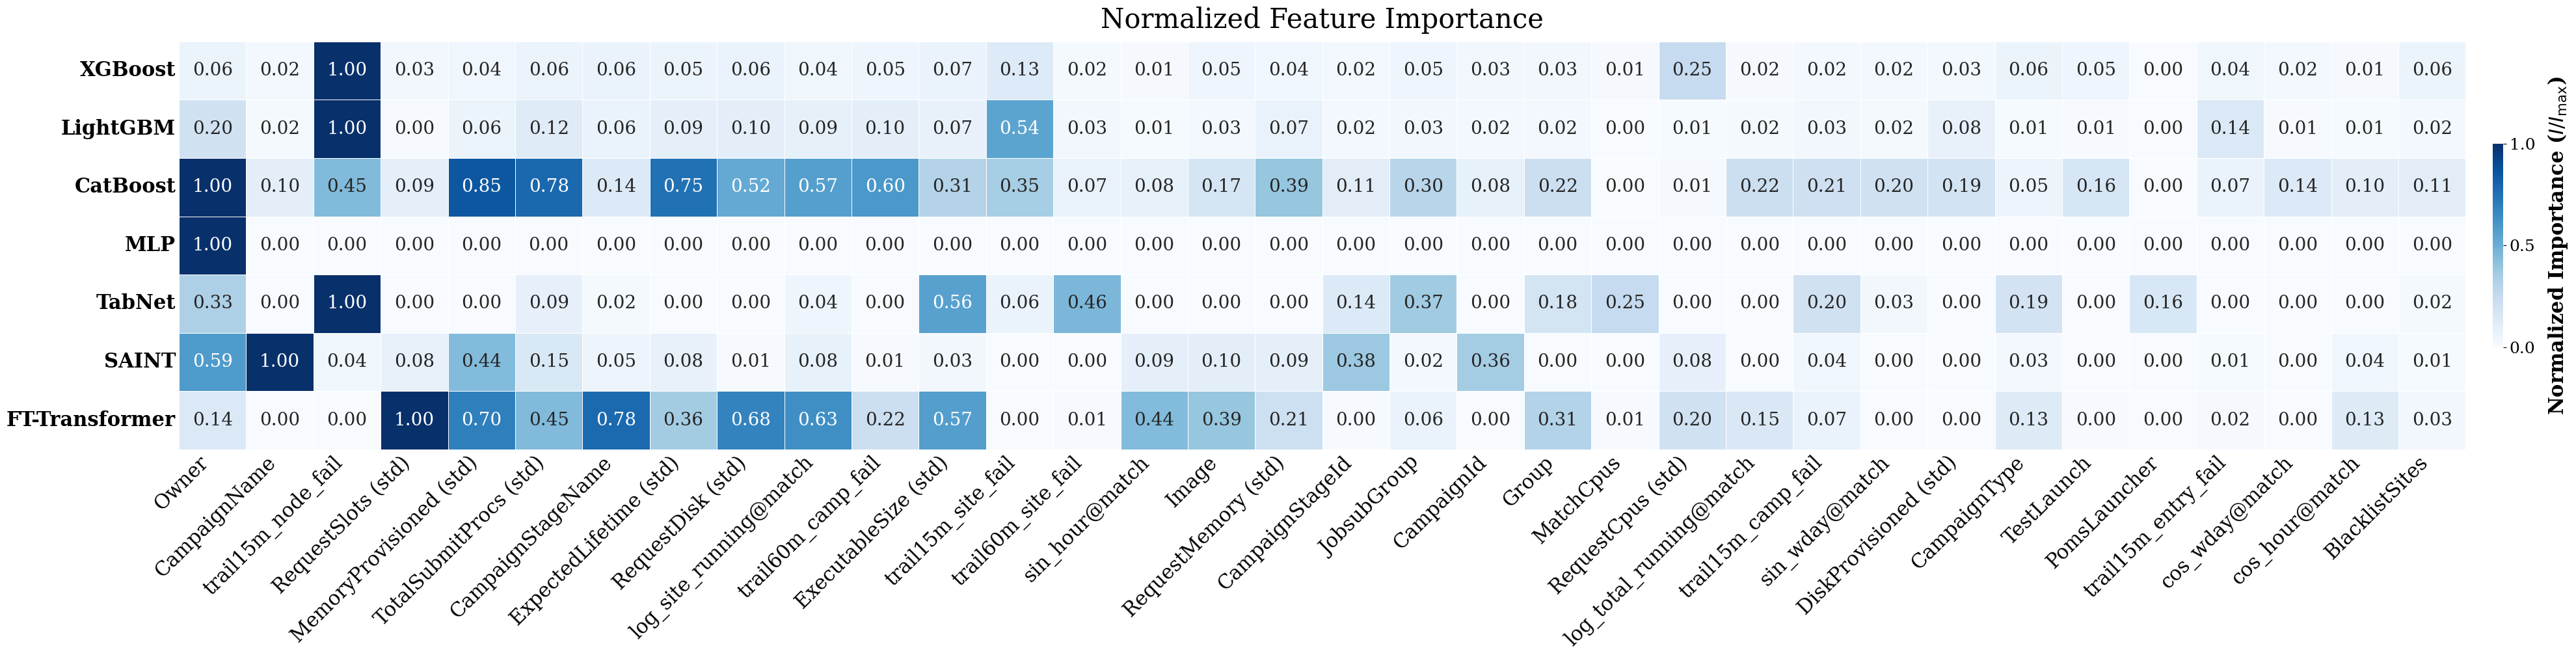

In [17]:
import importlib
import eval.helper

importlib.reload(eval.helper)
from eval.helper import imp_heatmap

df_norm = imp_heatmap(
    imp_dict=E1_IMP,
    feats=XMATCH_COLS,
    split_key="random",  
    cmap="Blues",  
)

/opt/nfs/home/amaustin/Research/fife-batch-jobs/scripts/eval/helper.py:1592: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


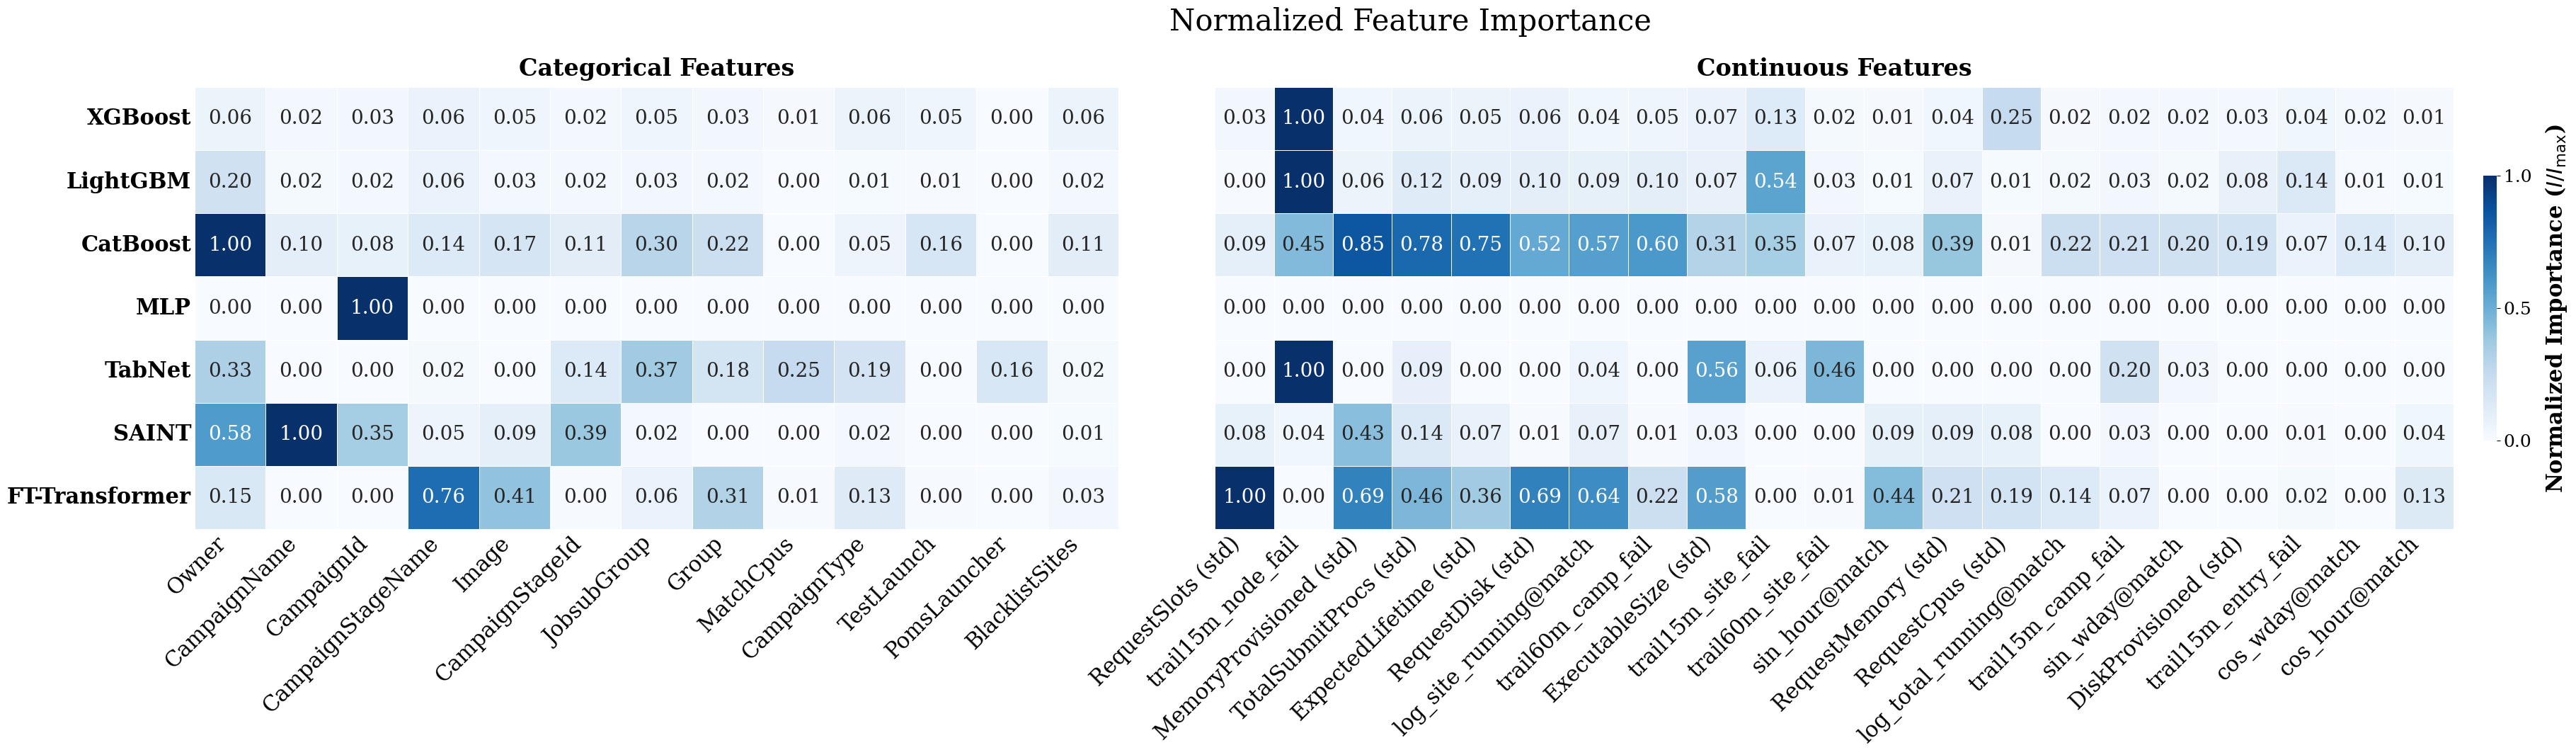

In [19]:
import importlib
import eval.helper

importlib.reload(eval.helper)
from eval.helper import feature_split_imp_heatmap

df_cat, df_non_cat = feature_split_imp_heatmap(
    imp_dict=E1_IMP,
    feats=XMATCH_COLS,
    n_cat=NCAT_MATCH,  
    split_key="random",
    cmap="Blues",
    output_prefix="feature_split_imp_heatmap",
)

#### Feature importance - temporal split

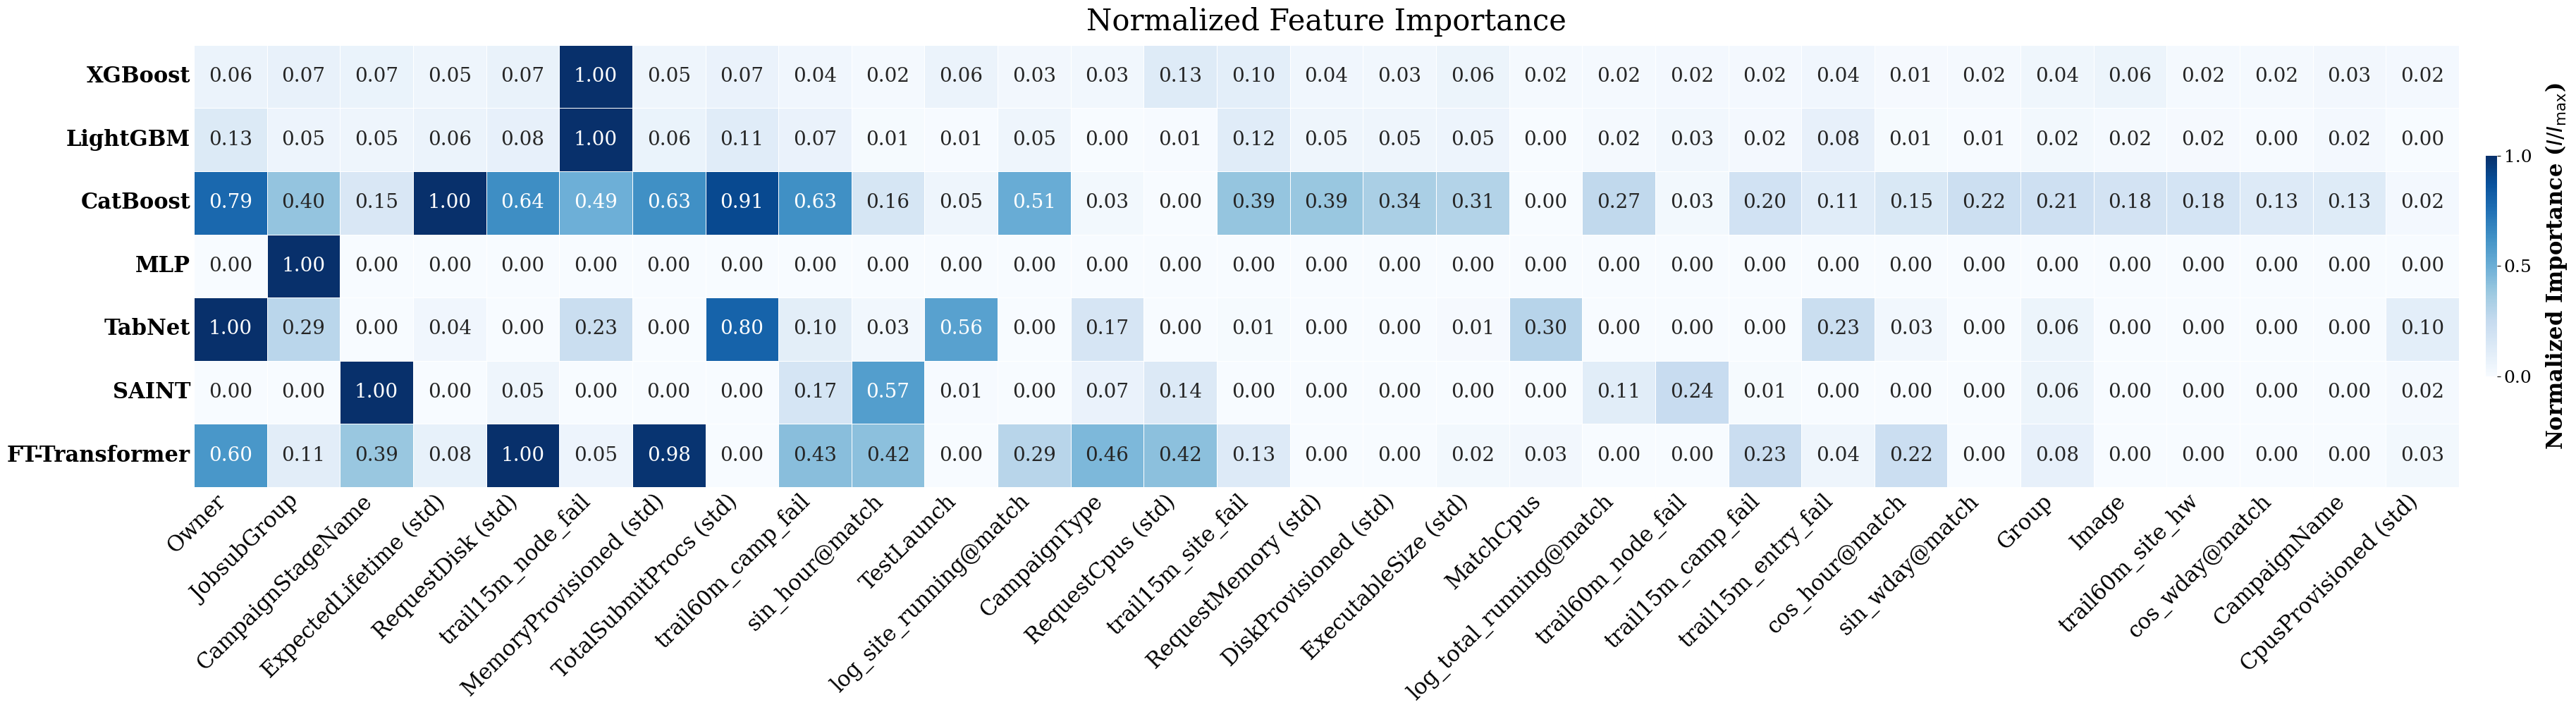

In [15]:
import importlib
import eval.helper

importlib.reload(eval.helper)
from eval.helper import imp_heatmap

df_norm = imp_heatmap(
    imp_dict=E1_IMP,
    feats=XMATCH_COLS,
    split_key="temporal",  
    cmap="Blues",  
)

/opt/nfs/home/amaustin/Research/fife-batch-jobs/scripts/eval/helper.py:1592: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


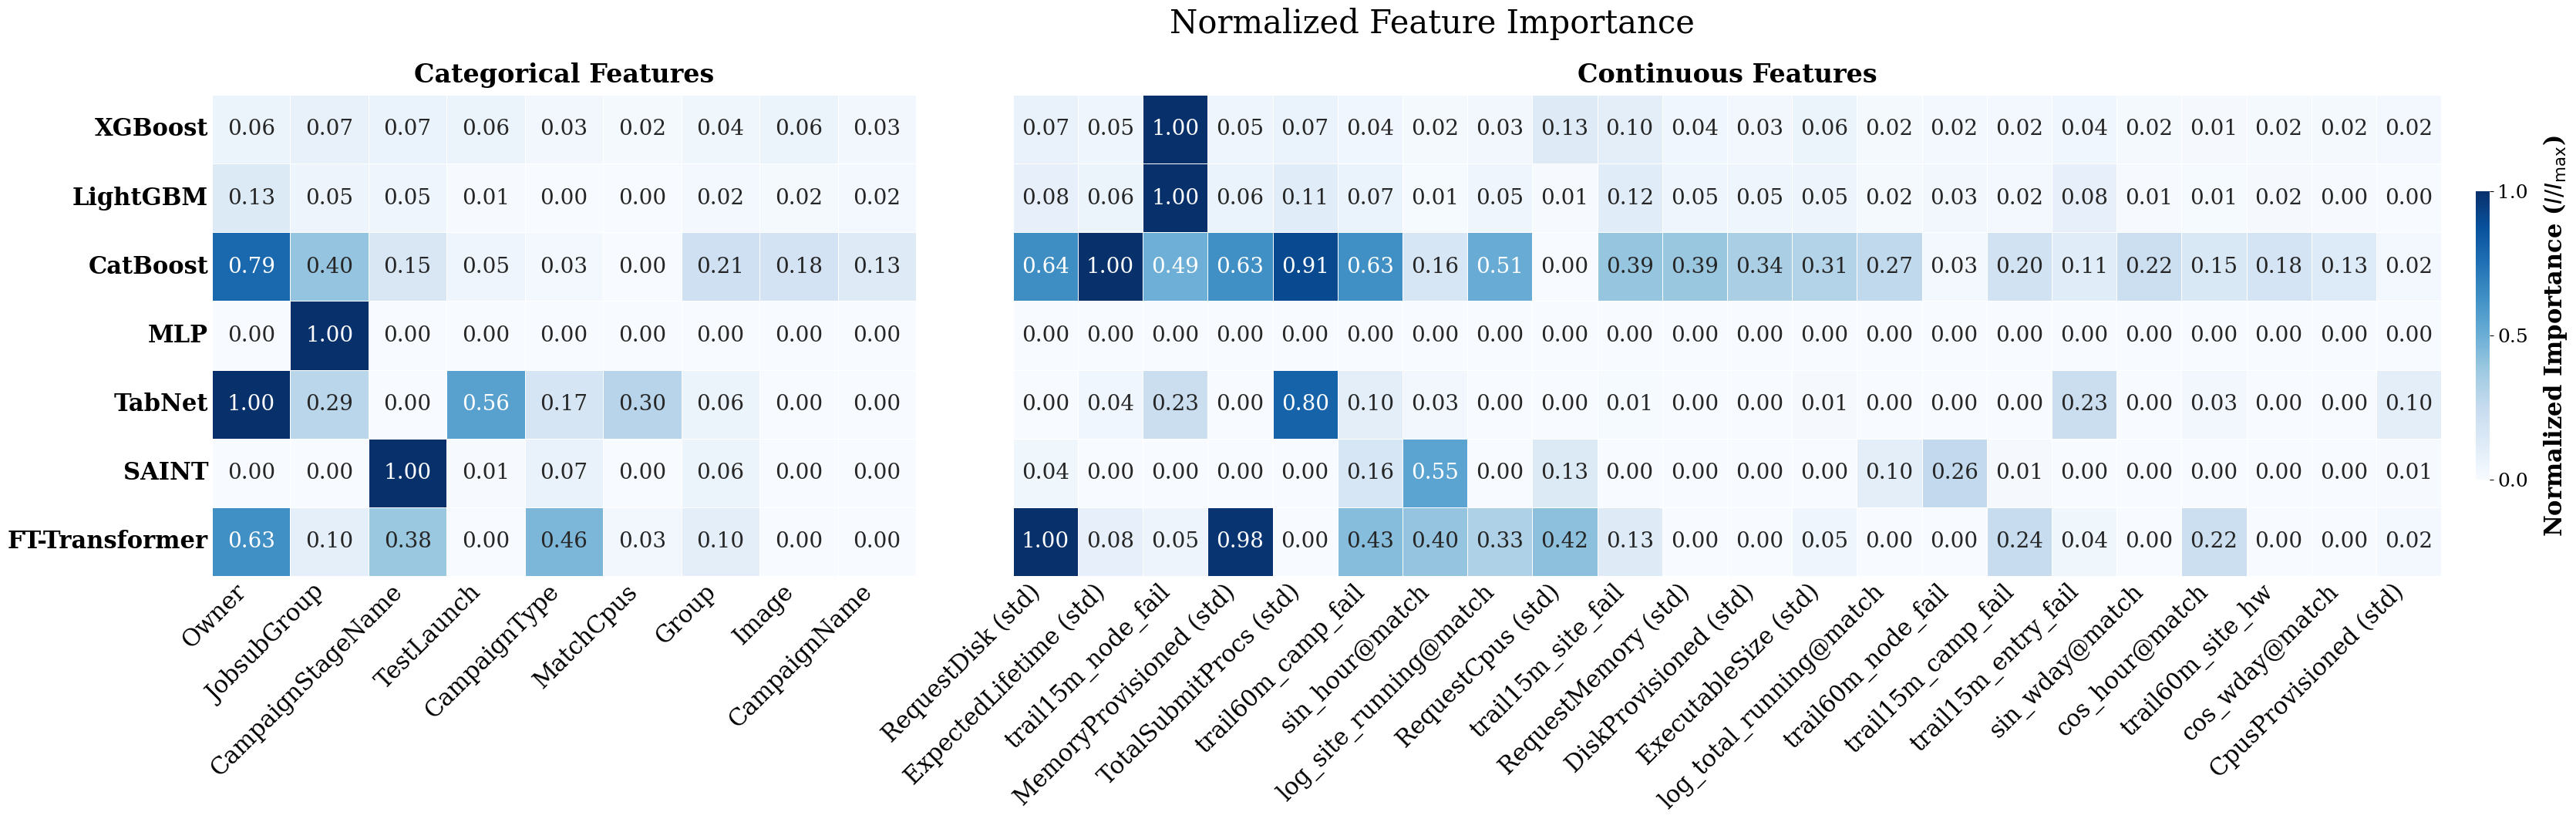

In [20]:
import importlib
import eval.helper

importlib.reload(eval.helper)
from eval.helper import feature_split_imp_heatmap

df_cat, df_non_cat = feature_split_imp_heatmap(
    imp_dict=E1_IMP,
    feats=XMATCH_COLS,
    n_cat=NCAT_MATCH,  
    split_key="temporal",
    cmap="Blues",
    output_prefix="feature_split_imp_heatmap",
)

### Feature gain shift (random split -> temporal)

/opt/nfs/home/amaustin/Research/fife-batch-jobs/scripts/eval/helper.py:2041: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


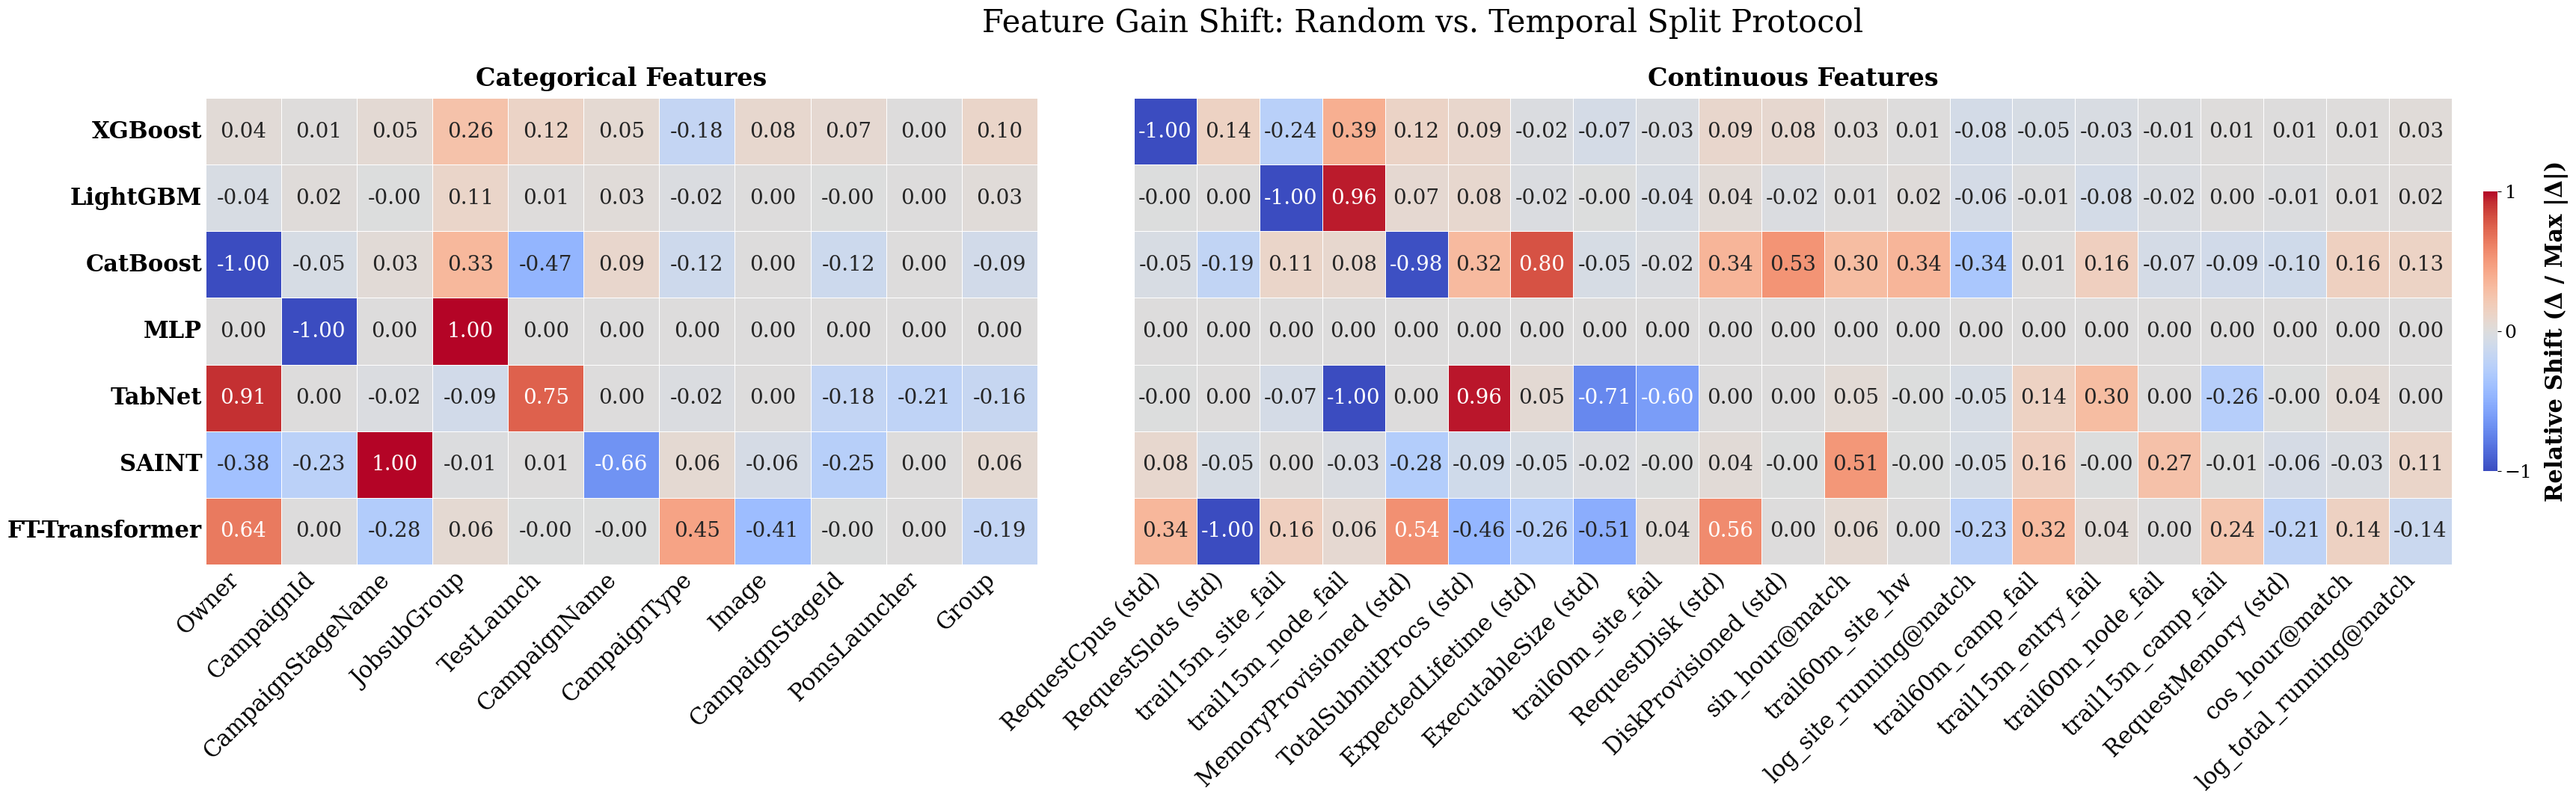

In [16]:
import importlib
import eval.helper

importlib.reload(eval.helper)
from eval.helper import imp_diff_heatmap

df_diff = imp_diff_heatmap(
    imp_dict=E1_IMP,
    feats=XMATCH_COLS,
    n_cat=NCAT_MATCH,  
    title="Feature Gain Shift: Random vs. Temporal Split Protocol",
    output_prefix="imp_diff_side_by_side",
)

#### Combined

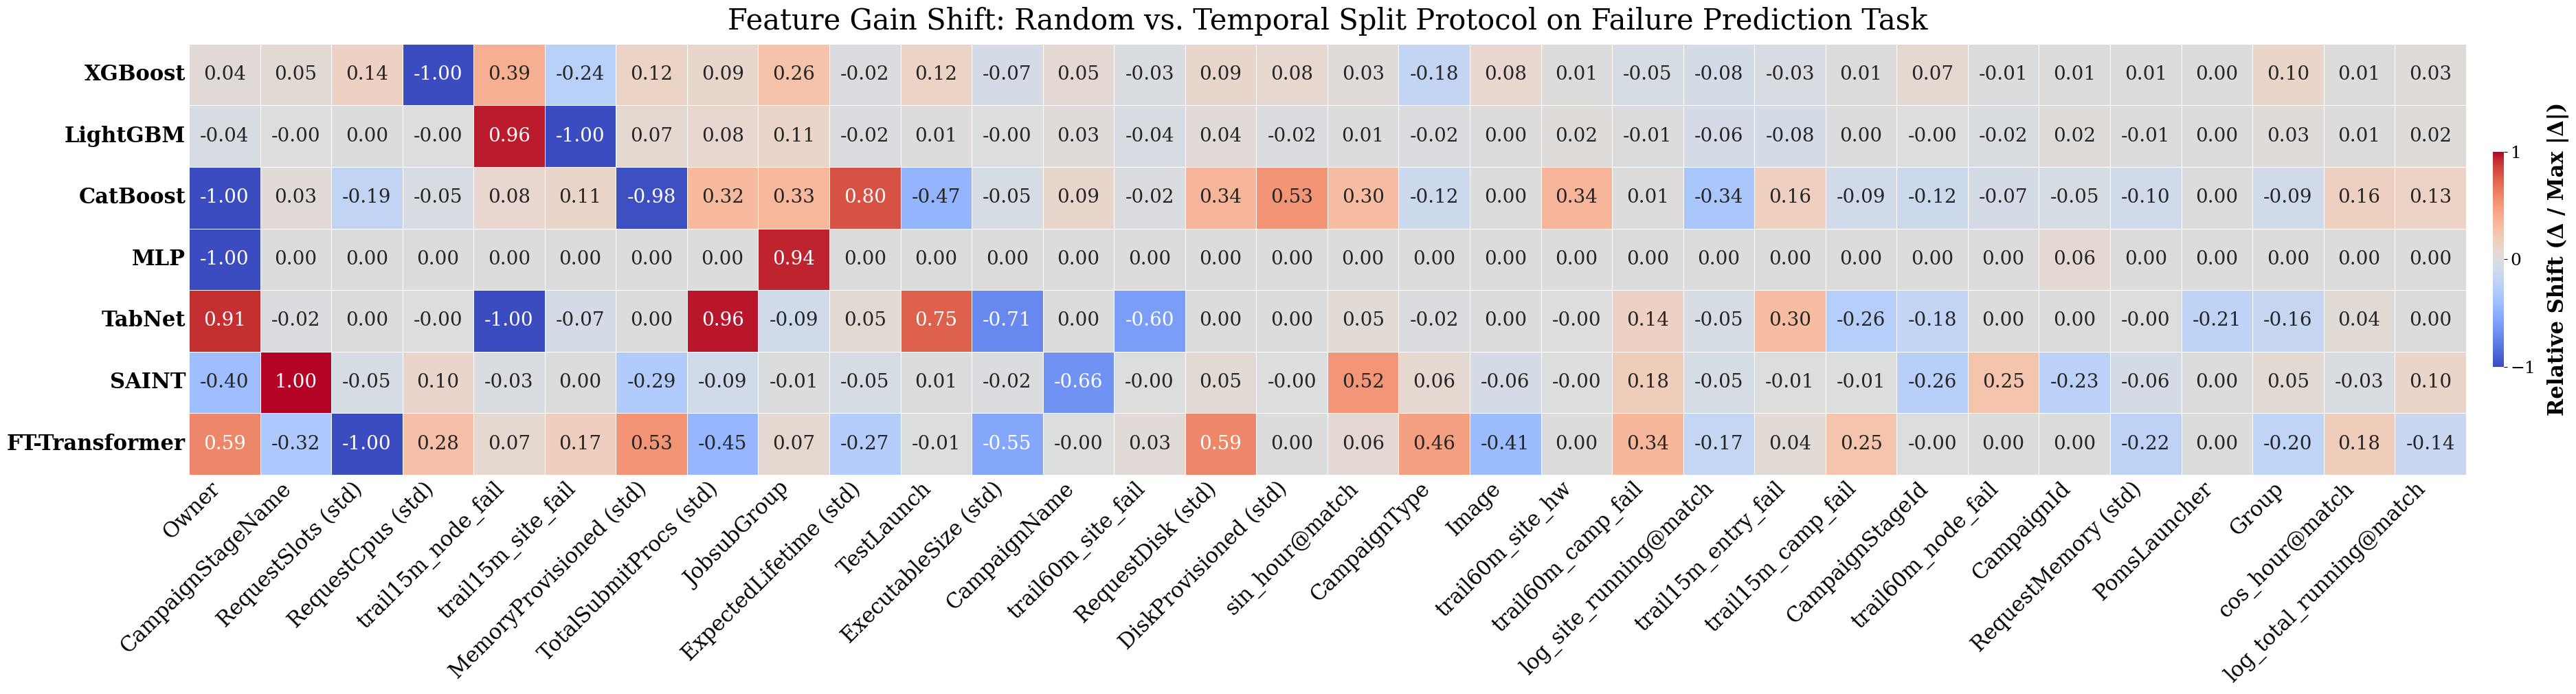

In [6]:
import eval.helper
importlib.reload(eval.helper)
from eval.helper import imp_diff_heatmap

imp_diff_heatmap(
    imp_dict=E1_IMP,
    feats=XMATCH_COLS,
)

Running evaluation only (on all models)

In [ ]:
import importlib
import eval.helper
importlib.reload(eval.helper)
from eval.helper import evaluate_protocol_models

results = evaluate_protocol_models(
    X_all=Xmatch,
    y_all=yv,
    rtr=rtr,  
    rte=rte, 
    tri_t=tri_t, 
    tei_t=tei_t, 
    output_path="output/protocol_eval_results.json",
)
results

In [ ]:
# Performance across evaluation protocols, with seed variance.
# Cut from five metrics to three (ROC-AUC / PR-AUC / F1) so the error bars have
# room; at ten bars per model they were unreadable. Aggregates every seed stored
# for a split ("temporal", "temporal__seed1", ...) and degrades to plain bars when
# only one seed exists.
import json
import os
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np
from eval.helper import aggregate_seeds

notebook_dir = os.getcwd()
RESULTS = os.path.join(notebook_dir, "results/protocol_eval_results.json")

MODEL_ORDER = {"xgboost":"XGBoost","lightgbm":"LightGBM","catboost":"CatBoost","mlp":"MLP",
               "tabnet":"TabNet","saint":"SAINT","ft":"FT-Transformer","tsmixer":"TSMixer"}
METRICS = [("roc_auc","ROC-AUC","#1b9e77"), ("pr_auc","PR-AUC","#e7298a"), ("f1","F1-Score","#7570b3")]
PROTOCOLS = [("random","Random",""), ("temporal","Temporal","//")]

with open(RESULTS) as f: results = json.load(f)
model_keys = [k for k in MODEL_ORDER if k in results]
models = [MODEL_ORDER[k] for k in model_keys]

def stat(mkey, split, metric):
    """mean, std across every seed stored for this model/split."""
    entry = results[mkey]
    runs = [v for k, v in entry.items() if k == split or k.startswith(f"{split}__seed")]
    if not runs: return np.nan, 0.0, 0
    agg = aggregate_seeds(runs)
    b = agg.get(metric)
    return (b["mean"], b["std"], b["n"]) if b else (np.nan, 0.0, 0)

plt.rcParams.update({"font.family":"serif","font.size":10,"axes.labelsize":12,
    "axes.titlesize":12,"xtick.labelsize":11,"ytick.labelsize":10,"legend.fontsize":9})

fig, ax = plt.subplots(figsize=(11, 3.6), dpi=300)
x = np.arange(len(models))
w = 0.13
n_bars = len(METRICS) * len(PROTOCOLS)
offsets = (np.arange(n_bars) - (n_bars - 1) / 2) * w

seed_counts = set()
i = 0
for mkey, mlabel, color in METRICS:
    for pkey, plabel, hatch in PROTOCOLS:
        vals, errs = [], []
        for k in model_keys:
            mu, sd, n = stat(k, pkey, mkey)
            vals.append(mu); errs.append(sd); seed_counts.add(n)
        ax.bar(x + offsets[i], vals, w, color=color, edgecolor="black", linewidth=0.5,
               hatch=hatch,
               # Error bars are +/-1 SD across seeds; absent when a single seed was run.
               yerr=errs if any(e > 0 for e in errs) else None,
               error_kw=dict(ecolor="black", elinewidth=0.9, capsize=2, capthick=0.9),
               zorder=3)
        i += 1

ax.set_ylabel("Score")
ax.set_xticks(x); ax.set_xticklabels(models)
ax.set_ylim(0, 1.05)
ax.grid(axis="y", linestyle="--", alpha=0.5); ax.set_axisbelow(True)
ns = sorted(n for n in seed_counts if n)
ax.set_title("Performance Comparison Across Evaluation Protocols (Random vs. Temporal)", pad=46)
# Seed provenance belongs on the figure, but under the axes so it cannot collide
# with the legends stacked above the title.
if ns and max(ns) > 1:
    rng_txt = f"{min(ns)}" + (f"-{max(ns)}" if min(ns) != max(ns) else "")
    note = f"Error bars: $\\pm$1 SD across {rng_txt} random seeds (identical configuration; seed varies weight init, batch order and dropout)."
else:
    note = "Single seed per configuration; no variance estimate available."
ax.annotate(note, xy=(0, -0.30), xycoords="axes fraction", fontsize=8.5,
            ha="left", va="top", color="0.30")

leg1 = ax.legend(handles=[Patch(facecolor=c, edgecolor="black", label=l) for _, l, c in METRICS],
                 title="Metric", loc="lower center", bbox_to_anchor=(0.42, 1.01), ncol=3,
                 frameon=True, facecolor="white", edgecolor="none")
ax.add_artist(leg1)
ax.legend(handles=[Patch(facecolor="white", edgecolor="black", hatch=h, label=l)
                   for _, l, h in PROTOCOLS],
          title="Split Protocol", loc="lower right", bbox_to_anchor=(1.0, 1.0), ncol=2,
          frameon=True, facecolor="white", edgecolor="none")

plt.tight_layout()

os.makedirs(os.path.join(notebook_dir, "output"), exist_ok=True)
pdf_path = os.path.join(notebook_dir, "output/protocol_ablation_summary.pdf")
png_path = os.path.join(notebook_dir, "output/protocol_ablation_summary.png")
plt.savefig(pdf_path, bbox_inches="tight")
plt.savefig(png_path, bbox_inches="tight", dpi=300)
plt.show()

print(f"Saved plots to:\n  - {pdf_path}\n  - {png_path}")
print(f"Seeds aggregated per bar: {sorted(n for n in seed_counts if n)}")
for k in model_keys:
    mu, sd, n = stat(k, "temporal", "pr_auc")
    print(f"  {MODEL_ORDER[k]:15s} temporal PR-AUC {mu:.4f} +/- {sd:.4f}  (n={n})")


### E1.5: Feature Ablation on Failed task (temporal split) 
`base -> +cyclical -> +campaign type -> +trailing site/campaign/node status` 